In [3]:
!pip install pandas numpy matplotlib scikit-learn
!pip install xgboost statsmodels prophet
!pip install openpyxl joblib

  Using cached prophet-1.3.0-py3-none-win_amd64.whl.metadata (3.6 kB)
  Using cached cmdstanpy-1.3.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached holidays-0.96-py3-none-any.whl.metadata (53 kB)
Using cached prophet-1.3.0-py3-none-win_amd64.whl (12.1 MB)
Using cached cmdstanpy-1.3.0-py3-none-any.whl (99 kB)
Using cached holidays-0.96-py3-none-any.whl (1.5 MB)


In [7]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from statsmodels.tsa.statespace.sarimax import SARIMAX

from prophet import Prophet

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import joblib

In [13]:
df = pd.read_excel('sales_data.xlsx')

df.head()

,State,Date,Total,Category
0,Alabama,2019-01-12 00:00:00,109574036.0,Beverages
1,Arizona,2019-01-12 00:00:00,109101594.6,Beverages
2,Arkansas,2019-01-12 00:00:00,58049432.2,Beverages
3,California,2019-01-12 00:00:00,444766890.6,Beverages
4,Colorado,2019-01-12 00:00:00,89816716.3,Beverages


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8084 entries, 0 to 8083
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   State     8084 non-null   object 
 1   Date      8084 non-null   object 
 2   Total     8084 non-null   float64
 3   Category  8084 non-null   object 
dtypes: float64(1), object(3)
memory usage: 252.8+ KB


In [19]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values(['State', 'Date'])

df['Total'] = (
    df['Total']
    .astype(str)
    .str.replace(',', '')
    .astype(float)
)

df['Total'] = df['Total'].ffill()

df.head()

,State,Date,Total,Category
0,Alabama,2019-01-12,109574036.0,Beverages
43,Alabama,2019-03-11,112189103.8,Beverages
86,Alabama,2019-06-10,129106730.4,Beverages
129,Alabama,2019-08-12,108083723.8,Beverages
172,Alabama,2019-10-11,110932912.8,Beverages


In [21]:
df['lag_1'] = df['Total'].shift(1)

df['lag_7'] = df['Total'].shift(7)

df['lag_30'] = df['Total'].shift(30)

df['rolling_mean_7'] = (
    df['Total']
    .rolling(7)
    .mean()
)
df['rolling_std_7'] = (
    df['Total']
    .rolling(7)
    .std()
)
df['day_of_week'] = (
    df['Date']
    .dt.dayofweek
)
df['month'] = (
    df['Date']
    .dt.month
)
df['quarter'] = (
    df['Date']
    .dt.quarter
)
df['holiday_flag'] = 0
df = df.dropna()
df.head()

,State,Date,Total,Category,lag_1,lag_7,lag_30,rolling_mean_7,rolling_std_7,day_of_week,month,quarter,holiday_flag
559,Alabama,2020-05-07,138414683.2,Beverages,123259529.2,127145065.2,109574036.0,1.217345e+08,1.143778e+07,3,5,2,0
4343,Alabama,2020-05-17,130340051.0,Beverages,138414683.2,116657084.0,112189103.8,1.236892e+08,1.159357e+07,6,5,2,0
6192,Alabama,2020-05-24,134708618.7,Beverages,130340051.0,133713630.0,129106730.4,1.238314e+08,1.174210e+07,6,5,2,0
7955,Alabama,2020-05-31,129887876.9,Beverages,134708618.7,117742073.2,108083723.8,1.255665e+08,1.158871e+07,6,5,2,0
602,Alabama,2020-06-09,137905687.0,Beverages,129887876.9,118114595.0,110932912.8,1.283938e+08,1.187827e+07,1,6,2,0


In [23]:
features = [
    'lag_1',
    'lag_7',
    'lag_30',
    'rolling_mean_7',
    'rolling_std_7',
    'day_of_week',
    'month',
    'quarter',
    'holiday_flag'
]

train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]

test = df.iloc[train_size:]

X_train = train[features]

y_train = train['Total']

X_test = test[features]

y_test = test['Total']

In [25]:
def evaluate(y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )
    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    return mae, rmse

In [27]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5
)
xgb_model.fit(
    X_train,
    y_train
)
xgb_predictions = xgb_model.predict(
    X_test
)
xgb_mae, xgb_rmse = evaluate(
    y_test,
    xgb_predictions
)
print('XGBoost RMSE:', xgb_rmse)

XGBoost RMSE: 30970062.42652094


In [29]:
arima_model = SARIMAX(
    y_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)
arima_result = arima_model.fit(
    disp=False
)
arima_predictions = (
    arima_result.forecast(
        len(y_test)
    )
)
arima_mae, arima_rmse = evaluate(
    y_test,
    arima_predictions
)
print('ARIMA RMSE:', arima_rmse)

C:\Users\vivek\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\vivek\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA RMSE: 216042262.66137812


C:\Users\vivek\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\vivek\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [31]:
prophet_df = df[
    ['Date', 'Total']
].copy()
prophet_df.columns = [
    'ds',
    'y'
]
prophet_train = prophet_df.iloc[
    :train_size
]
prophet_test = prophet_df.iloc[
    train_size:
]
prophet_model = Prophet()

prophet_model.fit(
    prophet_train
)
future = (
    prophet_model
    .make_future_dataframe(
        periods=len(prophet_test)
    )
)
forecast = prophet_model.predict(
    future
)
prophet_predictions = (
    forecast['yhat']
    .tail(len(prophet_test))
    .values
)
prophet_mae, prophet_rmse = evaluate(
    prophet_test['y'],
    prophet_predictions
)
print(
    'Prophet RMSE:',
    prophet_rmse
)

19:02:39 - cmdstanpy - INFO - Chain [1] start processing
19:02:40 - cmdstanpy - INFO - Chain [1] done processing


Prophet RMSE: 220423036.75223824


In [33]:
results = {
    'XGBoost': xgb_rmse,
    'ARIMA': arima_rmse,
    'Prophet': prophet_rmse
}
results_df = pd.DataFrame({
    'Model': results.keys(),
    'RMSE': results.values()
})
results_df

,Model,RMSE
0,XGBoost,3.097006e+07
1,ARIMA,2.160423e+08
2,Prophet,2.204230e+08


In [35]:
best_model = min(
    results,
    key=results.get
)
print(
    'Best Model:',
    best_model
)

Best Model: XGBoost


In [37]:
future_forecast = (
    xgb_predictions[-8:]
)
forecast_df = pd.DataFrame({
    'Forecast': future_forecast
})
forecast_df

,Forecast
0,22318860.0
1,22596136.0
2,22596136.0
3,22263728.0
4,23768550.0
5,21223498.0
6,22263728.0
7,22396004.0


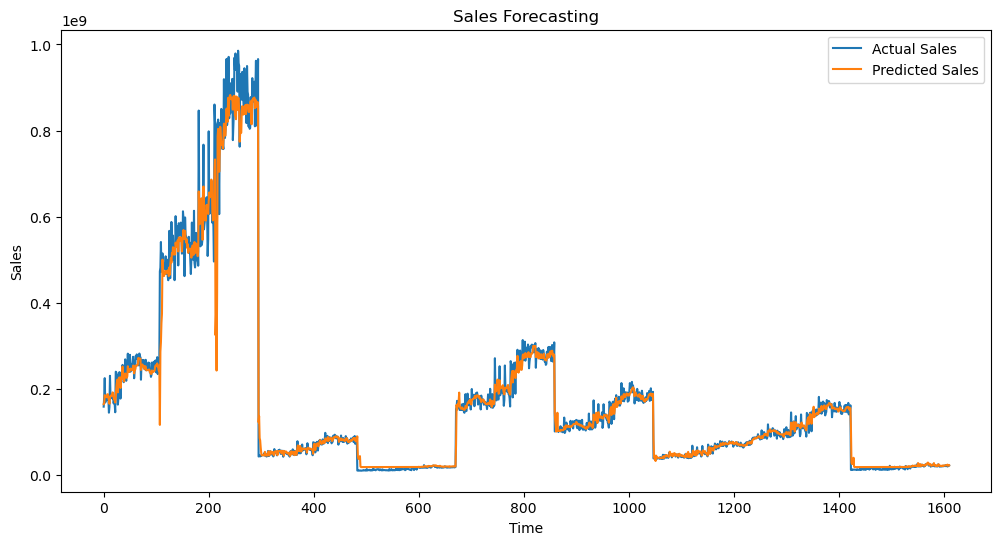

In [39]:
plt.figure(figsize=(12,6))

plt.plot(
    range(len(y_test)),
    y_test.values,
    label='Actual Sales'
)
plt.plot(
    range(len(xgb_predictions)),
    xgb_predictions,
    label='Predicted Sales'
)
plt.title(
    'Sales Forecasting'
)
plt.xlabel('Time')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [41]:
joblib.dump(
    xgb_model,
    'xgboost_model.pkl'
)
print(
    'Model Saved Successfully'
)

Model Saved Successfully
